# Where does the world waste its food?

A small analysis of the **UNEP Food Waste Index** (via Our World in Data):
how many kilograms of food each person wastes per year, by country, split into three places:

| Sector | What it means |
|---|---|
| **Household** | food thrown away at home |
| **Out-of-home consumption** | restaurants, canteens, hostel messes, hotels |
| **Retail** | shops and markets |

**Why I care:** I am building *Mess Saver*, an app that helps IIM Bangalore students give the hostel
mess advance notice of meals they will miss, so less food is cooked and wasted. This notebook puts
that problem in a global and Indian context.

**Questions**
1. Where in the food chain is most food wasted?
2. How does India compare with the world and other large countries?
3. Do richer countries waste more food at home?
4. What does this mean for a hostel mess like IIM Bangalore's?

## 1. Setup

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

CHARTS = Path("charts")
CHARTS.mkdir(exist_ok=True)

# Chart style: colour-blind-safe palette, light grid, no box around the chart
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#e4e3df"
plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "text.color": INK,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.8,
    "axes.axisbelow": True, "font.size": 11, "axes.titlesize": 14,
    "axes.titleweight": "bold", "axes.titlelocation": "left",
    "figure.dpi": 110, "savefig.dpi": 150, "savefig.bbox": "tight",
})

## 2. Load the data

Files in `data/` were downloaded from Our World in Data:
- `food-waste-per-capita.csv`: kg of food waste per person per year, by sector (UNEP Food Waste Index)
- `gdp-per-capita-worldbank.csv`: GDP per person, in international dollars (World Bank)

In [2]:
waste = pd.read_csv("data/food-waste-per-capita.csv")
waste.head()

,Entity,Code,Year,Retail,Out-of-home consumption,Household
0,Afghanistan,AFG,2019,15.75,27.85,82.32
1,Afghanistan,AFG,2022,9.68,32.49,127.15
2,Africa (UN),UN_AFR,2019,15.43,27.34,110.03
3,Africa (UN),UN_AFR,2022,10.05,31.11,99.49
4,Albania,ALB,2019,15.68,27.72,82.99


In [3]:
print("Rows, columns:", waste.shape)
print()
print("Rows per year:")
print(waste["Year"].value_counts().sort_index())

Rows, columns: (554, 6)

Rows per year:
Year
2008      1
2009      1
2010      1
2011      1
2012      1
2013      1
2014      1
2015      1
2016      1
2017      2
2018      2
2019    233
2020     29
2021     29
2022    250
Name: count, dtype: int64


## 3. Check the data

Things to look for before trusting any numbers:
- **Missing values**: blanks in a column.
- **Rows that are not countries**: the file also has groups like "World" or "Africa (UN)".
- **Impossible values**: e.g. 0 kg of waste.
- **Which year to use**: most countries have **2019** (UNEP's 2021 report) and **2022** (2024 report).

In [4]:
waste.isna().sum()

Entity                     0
Code                       5
Year                       0
Retail                     4
Out-of-home consumption    2
Household                  2
dtype: int64

In [5]:
# Real countries have a 3-letter ISO code (e.g. IND). Groups have none, or codes like UN_AFR / OWID_WRL.
is_country = waste["Code"].fillna("").str.fullmatch("[A-Z]{3}")
print(sorted(waste.loc[~is_country, "Entity"].unique()))

['Africa (UN)', 'Asia (UN)', 'Australia and New Zealand (UN SDG)', 'Central and Southern Asia (UN SDG)', 'Developing regions', 'Eastern and South-Eastern Asia (UN SDG)', 'Europe (UN)', 'Europe and Northern America (UN SDG)', 'Latin America and the Caribbean (UN SDG)', 'Latin America and the Caribbean (UN)', 'Least Developed Countries (LDCs)', 'Northern Africa and Western Asia (UN SDG)', 'Northern America (UN)', 'Oceania (UN SDG)', 'Oceania (UN)', 'Small Island Developing States (SIDS)', 'Sub-Saharan Africa (UN SDG)', 'World']


**Important caveat:** the 2019 and 2022 numbers come from two different UNEP reports that used
**different methods and more data** the second time. So a change between 2019 and 2022 is mostly
a change in *measurement*, not in behaviour. This notebook therefore uses **2022 only** and
does not claim any trend.

In [6]:
SECTORS = ["Household", "Out-of-home consumption", "Retail"]

w22 = waste[waste["Year"] == 2022].copy()
w22["Total"] = w22[SECTORS].sum(axis=1)

world = w22[w22["Entity"] == "World"].iloc[0]
countries = w22[is_country.loc[w22.index]].dropna(subset=SECTORS)

# A few tiny territories (Vatican, Niue, ...) show 0 kg: that means "no estimate", not "no waste"
no_estimate = countries["Total"] == 0
print("Dropped (0 kg = no estimate):", list(countries.loc[no_estimate, "Entity"]))
countries = countries[~no_estimate]

print(len(countries), "countries with complete 2022 data")
countries[["Entity"] + SECTORS + ["Total"]].describe().round(1)

Dropped (0 kg = no estimate): ['Falkland Islands', 'Montserrat', 'Niue', 'Tokelau', 'Vatican']
228 countries with complete 2022 data


,Household,Out-of-home consumption,Retail,Total
count,228.0,228.0,228.0,228.0
mean,87.5,31.1,16.1,134.6
std,26.2,11.9,10.6,34.5
min,17.8,2.0,1.0,39.0
25%,75.7,24.4,9.7,117.9
50%,88.6,31.1,13.3,132.8
75%,92.7,39.6,19.0,153.3
max,206.0,79.7,78.8,260.4


## 4. Question 1: Where is most food wasted?

In [7]:
share = (world[SECTORS] / world[SECTORS].sum() * 100).round(0)
pd.DataFrame({"kg per person per year": world[SECTORS].round(1), "% of total": share})

,kg per person per year,% of total
Household,79.1,60.0
Out-of-home consumption,36.3,28.0
Retail,16.4,12.0


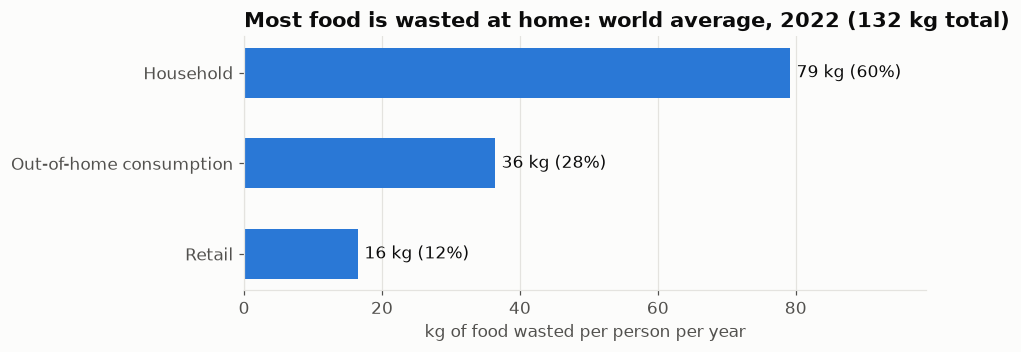

In [8]:
fig, ax = plt.subplots(figsize=(8, 3))
vals = world[SECTORS].astype(float)[::-1]          # biggest bar on top
bars = ax.barh(vals.index, vals.values, color=BLUE, height=0.55)
for bar, v in zip(bars, vals.values):
    ax.text(v + 1, bar.get_y() + bar.get_height() / 2,
            f"{v:.0f} kg ({v / vals.sum():.0%})", va="center", color=INK)
ax.set_xlim(0, vals.max() * 1.25)
ax.grid(axis="y", visible=False)
ax.set_xlabel("kg of food wasted per person per year")
ax.set_title(f"Most food is wasted at home: world average, 2022 ({vals.sum():.0f} kg total)")
fig.savefig(CHARTS / "01_world_by_sector.png")
plt.show()

**Finding:** roughly 6 in 10 kg of wasted food are thrown away **at home**. Restaurants, canteens
and messes are the second-largest source, which is the part *Mess Saver* targets.

*Next (Day 2): India vs other countries, waste vs wealth, and what this means for a hostel mess.*